# KAN Benchmarking v2: Improved with NAS-Guided Hyperparameters

Based on TabKAN paper insights:
- **Larger architectures**: depth 1-5, neurons 5-100
- **Proper tuning**: grid sizes, polynomial degrees per KAN type
- **ChebyKAN**: Paper's top performer for tabular data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


## 1. Load Data

In [2]:
# Load synthetic dataset
df = pd.read_excel('../data/High_Accuracy_Sport_Injury_Dataset.xlsx')
print(f"Dataset shape: {df.shape}")

X = df.drop('Injury_Risk', axis=1).values
y = df['Injury_Risk'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

n_features = X_train_scaled.shape[1]
print(f"Features: {n_features}, Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Dataset shape: (600, 16)
Features: 15, Train: 420, Val: 90, Test: 90


## 2. Training Utilities

In [3]:
results = []

def evaluate_model(model_name, y_true, y_pred, y_prob, train_time, inference_time, n_params):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5
    
    result = {
        'Model': model_name,
        'Accuracy': acc,
        'F1 Score': f1,
        'AUC-ROC': auc,
        'Train Time (s)': train_time,
        'Inference (ms)': inference_time * 1000,
        'Parameters': n_params
    }
    results.append(result)
    print(f"  {model_name}: Acc={acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}, Time={train_time:.2f}s")
    return result

def train_model(model, train_loader, epochs=200, lr=0.001, weight_decay=1e-4):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCELoss()
    
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
    return time.time() - start_time

def evaluate_pytorch(model, X_test_t, y_test):
    model.eval()
    model = model.to(device)
    start = time.time()
    with torch.no_grad():
        y_prob = model(X_test_t.to(device)).cpu().numpy().flatten()
    inference_time = time.time() - start
    y_pred = (y_prob > 0.5).astype(int)
    n_params = sum(p.numel() for p in model.parameters())
    return y_pred, y_prob, inference_time, n_params

## 3. Baselines

In [4]:
# XGBoost
print("Training baselines...")
start = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
train_time_xgb = time.time() - start
start = time.time()
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
inf_time_xgb = time.time() - start
evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb, train_time_xgb, inf_time_xgb, 799)

Training baselines...
  XGBoost: Acc=0.9444, F1=0.9057, AUC=0.9061, Time=0.14s


{'Model': 'XGBoost',
 'Accuracy': 0.9444444444444444,
 'F1 Score': 0.9056603773584906,
 'AUC-ROC': 0.9061059907834101,
 'Train Time (s)': 0.13931012153625488,
 'Inference (ms)': 1.6238689422607422,
 'Parameters': 799}

In [5]:
# MLP (Larger - based on paper)
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32]):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.3)])
            prev_dim = h
        layers.extend([nn.Linear(prev_dim, 1), nn.Sigmoid()])
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

mlp = MLP(n_features, [128, 64, 32])
train_time = train_model(mlp, train_loader, epochs=200)
y_pred, y_prob, inf_time, n_params = evaluate_pytorch(mlp, X_test_t, y_test)
evaluate_model('MLP (Tuned)', y_test, y_pred, y_prob, train_time, inf_time, n_params)

  MLP (Tuned): Acc=0.8556, F1=0.7451, AUC=0.8687, Time=14.39s


{'Model': 'MLP (Tuned)',
 'Accuracy': 0.8555555555555555,
 'F1 Score': 0.7450980392156863,
 'AUC-ROC': 0.868663594470046,
 'Train Time (s)': 14.392936944961548,
 'Inference (ms)': 19.560813903808594,
 'Parameters': 12865}

## 4. Improved KAN Implementations (Paper-Guided)

In [6]:
# efficient-kan with larger architecture
try:
    from efficient_kan import KAN as EfficientKAN
    
    class EfficientKANClassifier(nn.Module):
        def __init__(self, layers, grid_size=5, spline_order=3):
            super().__init__()
            self.kan = EfficientKAN(layers, grid_size=grid_size, spline_order=spline_order)
            self.sigmoid = nn.Sigmoid()
        def forward(self, x): return self.sigmoid(self.kan(x))
    
    # Paper recommends depth 1-5, neurons 5-100
    print("\nTraining efficient-kan (improved)...")
    ekan = EfficientKANClassifier([n_features, 64, 32, 16, 1], grid_size=8, spline_order=3)
    train_time = train_model(ekan, train_loader, epochs=200, lr=0.005)
    y_pred, y_prob, inf_time, n_params = evaluate_pytorch(ekan, X_test_t, y_test)
    evaluate_model('efficient-kan (Tuned)', y_test, y_pred, y_prob, train_time, inf_time, n_params)
except Exception as e:
    print(f"efficient-kan failed: {e}")


Training efficient-kan (improved)...


  efficient-kan (Tuned): Acc=0.8222, F1=0.6800, AUC=0.8571, Time=20.52s


In [7]:
# Improved ChebyKAN (Paper's top performer)
class ChebyKANLayer(nn.Module):
    def __init__(self, in_features, out_features, degree=5):
        super().__init__()
        self.degree = degree
        self.in_features = in_features
        self.out_features = out_features
        # Separate coefficients per input-output pair (paper approach)
        self.coeffs = nn.Parameter(torch.randn(in_features, out_features, degree + 1) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_features))
    
    def forward(self, x):
        # x: (batch, in_features)
        x_norm = torch.tanh(x)  # Normalize to [-1, 1]
        
        # Chebyshev recurrence: T_0=1, T_1=x, T_n = 2x*T_{n-1} - T_{n-2}
        T = [torch.ones_like(x_norm), x_norm]
        for _ in range(2, self.degree + 1):
            T.append(2 * x_norm * T[-1] - T[-2])
        
        T = torch.stack(T, dim=-1)  # (batch, in_features, degree+1)
        
        # Compute output: sum over input features and polynomial terms
        out = torch.einsum('bid,iod->bo', T, self.coeffs) + self.bias
        return out

class ChebyKAN(nn.Module):
    def __init__(self, layers_dims, degree=5):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers_dims) - 1):
            self.layers.append(ChebyKANLayer(layers_dims[i], layers_dims[i+1], degree))
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("\nTraining ChebyKAN (Tuned - Paper's best)...")
# Paper: degree 2-6, depth 1-5, neurons 5-100
cheby = ChebyKAN([n_features, 64, 32, 16, 1], degree=5)
train_time = train_model(cheby, train_loader, epochs=200, lr=0.003)
y_pred, y_prob, inf_time, n_params = evaluate_pytorch(cheby, X_test_t, y_test)
evaluate_model('ChebyKAN (Tuned)', y_test, y_pred, y_prob, train_time, inf_time, n_params)


Training ChebyKAN (Tuned - Paper's best)...


  ChebyKAN (Tuned): Acc=0.8667, F1=0.7692, AUC=0.8105, Time=23.57s


{'Model': 'ChebyKAN (Tuned)',
 'Accuracy': 0.8666666666666667,
 'F1 Score': 0.7692307692307693,
 'AUC-ROC': 0.8104838709677419,
 'Train Time (s)': 23.56813907623291,
 'Inference (ms)': 190.55676460266113,
 'Parameters': 21329}

In [8]:
# Improved FourierKAN
class FourierKANLayer(nn.Module):
    def __init__(self, in_features, out_features, grid_size=8):
        super().__init__()
        self.grid_size = grid_size
        # Cosine and sine coefficients
        self.a = nn.Parameter(torch.randn(in_features, out_features, grid_size) * 0.1)
        self.b = nn.Parameter(torch.randn(in_features, out_features, grid_size) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_features))
        # Learnable frequency scaling
        self.freq_scale = nn.Parameter(torch.ones(1))
    
    def forward(self, x):
        # x: (batch, in_features)
        freqs = torch.arange(1, self.grid_size + 1, device=x.device).float() * self.freq_scale
        x_exp = x.unsqueeze(-1)  # (batch, in_features, 1)
        
        cos_terms = torch.cos(freqs * x_exp * np.pi)  # (batch, in, grid_size)
        sin_terms = torch.sin(freqs * x_exp * np.pi)
        
        out = torch.einsum('big,iog->bo', cos_terms, self.a) + torch.einsum('big,iog->bo', sin_terms, self.b)
        return out + self.bias

class FourierKAN(nn.Module):
    def __init__(self, layers_dims, grid_size=8):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers_dims) - 1):
            self.layers.append(FourierKANLayer(layers_dims[i], layers_dims[i+1], grid_size))
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("\nTraining FourierKAN (Tuned)...")
# Paper: grid_size 1-10
fourier = FourierKAN([n_features, 64, 32, 16, 1], grid_size=8)
train_time = train_model(fourier, train_loader, epochs=200, lr=0.003)
y_pred, y_prob, inf_time, n_params = evaluate_pytorch(fourier, X_test_t, y_test)
evaluate_model('FourierKAN (Tuned)', y_test, y_pred, y_prob, train_time, inf_time, n_params)


Training FourierKAN (Tuned)...


  FourierKAN (Tuned): Acc=0.6889, F1=0.0000, AUC=0.6066, Time=27.92s


{'Model': 'FourierKAN (Tuned)',
 'Accuracy': 0.6888888888888889,
 'F1 Score': 0.0,
 'AUC-ROC': 0.6065668202764978,
 'Train Time (s)': 27.915707111358643,
 'Inference (ms)': 143.01085472106934,
 'Parameters': 56693}

In [9]:
# Improved FastKAN (RBF-based)
class RBFKANLayer(nn.Module):
    def __init__(self, in_features, out_features, num_centers=16):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_centers = num_centers
        
        # Learnable centers and bandwidths
        self.centers = nn.Parameter(torch.linspace(-2, 2, num_centers).unsqueeze(0).unsqueeze(0).repeat(in_features, out_features, 1))
        self.log_bandwidths = nn.Parameter(torch.zeros(in_features, out_features, num_centers))
        self.weights = nn.Parameter(torch.randn(in_features, out_features, num_centers) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_features))
    
    def forward(self, x):
        # x: (batch, in_features)
        x_exp = x.unsqueeze(2).unsqueeze(3)  # (batch, in, 1, 1)
        bandwidths = torch.exp(self.log_bandwidths) + 0.1  # Ensure positive
        
        # RBF: exp(-||x-c||^2 / (2h^2))
        rbf = torch.exp(-((x_exp - self.centers) ** 2) / (2 * bandwidths ** 2))
        
        out = (rbf * self.weights).sum(dim=-1).sum(dim=1) + self.bias
        return out

class FastKAN(nn.Module):
    def __init__(self, layers_dims, num_centers=16):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers_dims) - 1):
            self.layers.append(RBFKANLayer(layers_dims[i], layers_dims[i+1], num_centers))
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("\nTraining FastKAN (Tuned)...")
fastkan = FastKAN([n_features, 48, 24, 1], num_centers=16)
train_time = train_model(fastkan, train_loader, epochs=200, lr=0.003)
y_pred, y_prob, inf_time, n_params = evaluate_pytorch(fastkan, X_test_t, y_test)
evaluate_model('FastKAN (Tuned)', y_test, y_pred, y_prob, train_time, inf_time, n_params)


Training FastKAN (Tuned)...


  FastKAN (Tuned): Acc=0.8444, F1=0.7407, AUC=0.8848, Time=11.99s


{'Model': 'FastKAN (Tuned)',
 'Accuracy': 0.8444444444444444,
 'F1 Score': 0.7407407407407407,
 'AUC-ROC': 0.8847926267281107,
 'Train Time (s)': 11.986337661743164,
 'Inference (ms)': 24.466991424560547,
 'Parameters': 91081}

In [10]:
# Improved Wav-KAN with learnable wavelets
class WaveletKANLayer(nn.Module):
    def __init__(self, in_features, out_features, num_wavelets=16):
        super().__init__()
        self.translations = nn.Parameter(torch.linspace(-3, 3, num_wavelets).unsqueeze(0).unsqueeze(0).repeat(in_features, out_features, 1))
        self.log_scales = nn.Parameter(torch.zeros(in_features, out_features, num_wavelets))
        self.weights = nn.Parameter(torch.randn(in_features, out_features, num_wavelets) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_features))
    
    def mexican_hat(self, x):
        return (1 - x**2) * torch.exp(-x**2 / 2)
    
    def forward(self, x):
        x_exp = x.unsqueeze(2).unsqueeze(3)
        scales = torch.exp(self.log_scales) + 0.1
        x_norm = (x_exp - self.translations) / scales
        wavelet_out = self.mexican_hat(x_norm)
        out = (wavelet_out * self.weights).sum(dim=-1).sum(dim=1) + self.bias
        return out

class WavKAN(nn.Module):
    def __init__(self, layers_dims, num_wavelets=16):
        super().__init__()
        self.layers = nn.ModuleList([WaveletKANLayer(layers_dims[i], layers_dims[i+1], num_wavelets) for i in range(len(layers_dims)-1)])
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("\nTraining Wav-KAN (Tuned)...")
wavkan = WavKAN([n_features, 48, 24, 1], num_wavelets=16)
train_time = train_model(wavkan, train_loader, epochs=200, lr=0.003)
y_pred, y_prob, inf_time, n_params = evaluate_pytorch(wavkan, X_test_t, y_test)
evaluate_model('Wav-KAN (Tuned)', y_test, y_pred, y_prob, train_time, inf_time, n_params)


Training Wav-KAN (Tuned)...


  Wav-KAN (Tuned): Acc=0.7778, F1=0.4737, AUC=0.7955, Time=11.28s


{'Model': 'Wav-KAN (Tuned)',
 'Accuracy': 0.7777777777777778,
 'F1 Score': 0.47368421052631576,
 'AUC-ROC': 0.7955069124423964,
 'Train Time (s)': 11.276388883590698,
 'Inference (ms)': 4.595041275024414,
 'Parameters': 91081}

## 5. Results Comparison

In [11]:
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("IMPROVED BENCHMARK RESULTS (Paper-Guided Hyperparameters)")
print("="*80)
display(results_df.round(4))


IMPROVED BENCHMARK RESULTS (Paper-Guided Hyperparameters)


,Model,Accuracy,F1 Score,AUC-ROC,Train Time (s),Inference (ms),Parameters
0,XGBoost,0.9444,0.9057,0.9061,0.1393,1.6239,799
3,ChebyKAN (Tuned),0.8667,0.7692,0.8105,23.5681,190.5568,21329
1,MLP (Tuned),0.8556,0.7451,0.8687,14.3929,19.5608,12865
5,FastKAN (Tuned),0.8444,0.7407,0.8848,11.9863,24.4670,91081
2,efficient-kan (Tuned),0.8222,0.6800,0.8571,20.5159,217.9899,45968
6,Wav-KAN (Tuned),0.7778,0.4737,0.7955,11.2764,4.5950,91081
4,FourierKAN (Tuned),0.6889,0.0000,0.6066,27.9157,143.0109,56693


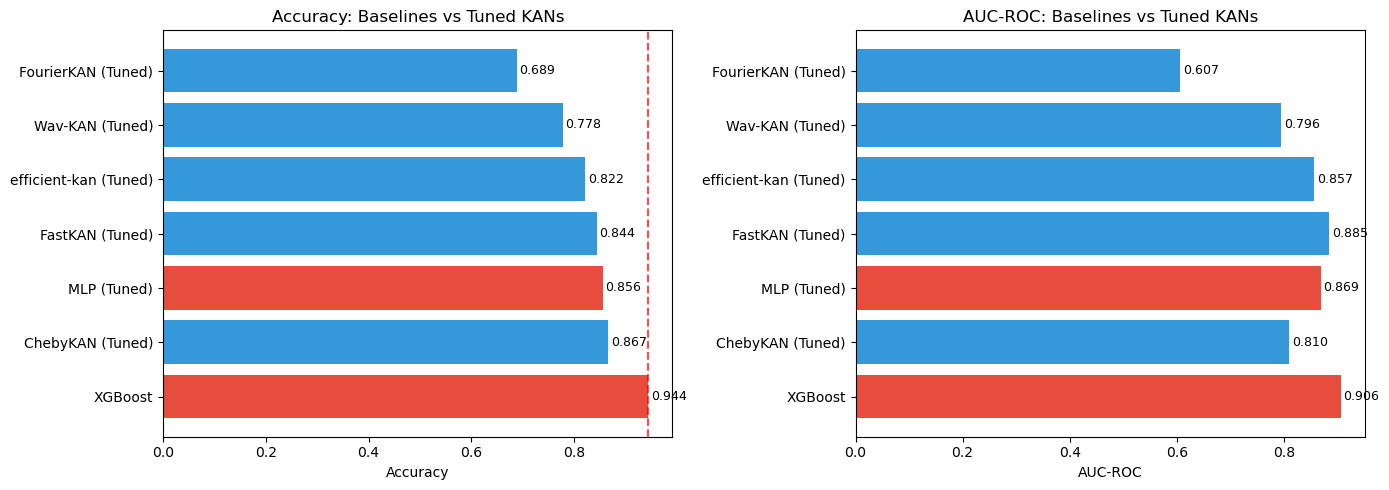


🔴 Red = Baselines | 🔵 Blue = Tuned KAN variants


In [12]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if 'XGBoost' in m or 'MLP' in m else '#3498db' for m in results_df['Model']]

ax1 = axes[0]
bars = ax1.barh(results_df['Model'], results_df['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy')
ax1.set_title('Accuracy: Baselines vs Tuned KANs')
ax1.axvline(x=results_df[results_df['Model']=='XGBoost']['Accuracy'].values[0], color='red', linestyle='--', alpha=0.7, label='XGBoost baseline')
for bar, val in zip(bars, results_df['Accuracy']):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

ax2 = axes[1]
bars = ax2.barh(results_df['Model'], results_df['AUC-ROC'], color=colors)
ax2.set_xlabel('AUC-ROC')
ax2.set_title('AUC-ROC: Baselines vs Tuned KANs')
for bar, val in zip(bars, results_df['AUC-ROC']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/benchmark_v2_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔴 Red = Baselines | 🔵 Blue = Tuned KAN variants")

In [13]:
print("\n" + "="*80)
print("KEY FINDINGS - TUNED MODELS")
print("="*80)

best = results_df.iloc[0]
kan_models = results_df[results_df['Model'].str.contains('KAN')]
baselines = results_df[~results_df['Model'].str.contains('KAN')]

print(f"\n🏆 Best Overall: {best['Model']} ({best['Accuracy']:.4f})")
if len(kan_models) > 0:
    best_kan = kan_models.iloc[0]
    print(f"🧠 Best KAN: {best_kan['Model']} ({best_kan['Accuracy']:.4f})")
    
    xgb_acc = baselines[baselines['Model']=='XGBoost']['Accuracy'].values[0]
    gap = best_kan['Accuracy'] - xgb_acc
    print(f"\n📊 Gap to XGBoost: {gap:+.4f} ({'AHEAD' if gap > 0 else 'behind'})")
    print(f"📊 Average KAN Accuracy: {kan_models['Accuracy'].mean():.4f}")
    print(f"📊 Average Baseline Accuracy: {baselines['Accuracy'].mean():.4f}")


KEY FINDINGS - TUNED MODELS

🏆 Best Overall: XGBoost (0.9444)
🧠 Best KAN: ChebyKAN (Tuned) (0.8667)

📊 Gap to XGBoost: -0.0778 (behind)
📊 Average KAN Accuracy: 0.7944
📊 Average Baseline Accuracy: 0.8741
